# Bellabeat / FitBit Fitness Tracker Data — Exploratory Data Analysis

Standalone EDA notebook (works as a plain script, or open in Jupyter /
VS Code and run cell-by-cell using the `# %%` markers).

Reads directly from the raw Fitabase CSVs in `data/` — no database
required — so this can be run and presented completely on its own.

Sections:
1. Load & inspect
2. Data quality (missing values, duplicates, ranges)
3. Descriptive statistics
4. Univariate analysis (steps, calories, sleep)
5. Bivariate / correlation analysis
6. Time-based patterns (day-of-week, hour-of-day)
7. Sleep deep-dive
8. Outlier check
9. Summary of findings

In [1]:
import warnings
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # comment this out if running interactively in Jupyter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")

DATA_DIR = Path(__file__).parent.parent / "data"
FIG_DIR = Path(__file__).parent / "eda_figures_full"
FIG_DIR.mkdir(exist_ok=True)

WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


def savefig(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / name, dpi=150)
    plt.close(fig)
    print(f"  saved: {name}")


def section(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

## 1. Load & inspect

In [2]:
section("1. LOAD & INSPECT")

activity = pd.read_csv(DATA_DIR / "dailyActivity_merged.csv")
sleep = pd.read_csv(DATA_DIR / "sleepDay_merged.csv")
weight = pd.read_csv(DATA_DIR / "weightLogInfo_merged.csv")
hourly_steps = pd.read_csv(DATA_DIR / "hourlySteps_merged.csv")
hourly_calories = pd.read_csv(DATA_DIR / "hourlyCalories_merged.csv")
hourly_intensities = pd.read_csv(DATA_DIR / "hourlyIntensities_merged.csv")

for name, df in [("dailyActivity", activity), ("sleepDay", sleep), ("weightLogInfo", weight),
                  ("hourlySteps", hourly_steps), ("hourlyCalories", hourly_calories),
                  ("hourlyIntensities", hourly_intensities)]:
    print(f"{name:20s} shape={df.shape}  users={df['Id'].nunique()}")

print("\ndailyActivity columns:\n", list(activity.columns))
print("\ndailyActivity head:\n", activity.head(3))


1. LOAD & INSPECT
dailyActivity        shape=(940, 15)  users=33
sleepDay             shape=(413, 5)  users=24
weightLogInfo        shape=(67, 8)  users=8
hourlySteps          shape=(22099, 3)  users=33
hourlyCalories       shape=(22099, 3)  users=33
hourlyIntensities    shape=(22099, 4)  users=33

dailyActivity columns:
 ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']

dailyActivity head:
            Id ActivityDate  ...  SedentaryMinutes  Calories
0  1503960366    4/12/2016  ...               728      1985
1  1503960366    4/13/2016  ...               776      1797
2  1503960366    4/14/2016  ...              1218      1776

[3 rows x 15 columns]


## 2. Data quality: missing values, duplicates, date parsing, ranges

In [3]:
section("2. DATA QUALITY")

print("Missing values per column (dailyActivity):")
missing_act = activity.isna().sum()
print(missing_act[missing_act > 0] if missing_act.any() else "  none")

print("\nMissing values per column (sleepDay):")
missing_sleep = sleep.isna().sum()
print(missing_sleep[missing_sleep > 0] if missing_sleep.any() else "  none")

print("\nMissing values per column (weightLogInfo):")
print(weight.isna().sum())  # Fat is expected to be mostly missing

print(f"\nDuplicate rows -- activity: {activity.duplicated().sum()}, "
      f"sleep: {sleep.duplicated().sum()}, weight: {weight.duplicated().sum()}")

# Parse dates
activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"], format="%m/%d/%Y")
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"], format="%m/%d/%Y %I:%M:%S %p").dt.normalize()
weight["Date"] = pd.to_datetime(weight["Date"], format="%m/%d/%Y %I:%M:%S %p")
for hdf in (hourly_steps, hourly_calories, hourly_intensities):
    hdf["ActivityHour"] = pd.to_datetime(hdf["ActivityHour"], format="%m/%d/%Y %I:%M:%S %p")

print(f"\nDate range: {activity['ActivityDate'].min().date()} to {activity['ActivityDate'].max().date()}")

# Sanity-check ranges (catch impossible values before analysing)
print("\nRange checks:")
print(f"  TotalSteps      min={activity.TotalSteps.min()}   max={activity.TotalSteps.max()}")
print(f"  Calories        min={activity.Calories.min()}   max={activity.Calories.max()}")
print(f"  SedentaryMinutes max={activity.SedentaryMinutes.max()} (1440 = full day)")

# Same-day duplicate sleep sessions (naps logged separately)
dup_sleep_days = sleep.groupby(["Id", "SleepDay"]).size()
print(f"\n{ (dup_sleep_days > 1).sum() } Id/day combinations have >1 sleep record logged (naps) "
      f"out of {len(dup_sleep_days)} total")

# No-wear days: zero steps AND zero active minutes logged
activity["TotalActiveMinutes"] = (
    activity["VeryActiveMinutes"] + activity["FairlyActiveMinutes"] + activity["LightlyActiveMinutes"]
)
activity["IsNoWearDay"] = (activity["TotalSteps"] == 0) & (activity["TotalActiveMinutes"] == 0)
print(f"\nNo-wear days flagged: {activity['IsNoWearDay'].sum()} of {len(activity)} "
      f"({100*activity['IsNoWearDay'].mean():.1f}%)")

activity["DayOfWeek"] = activity["ActivityDate"].dt.day_name()


2. DATA QUALITY
Missing values per column (dailyActivity):
  none

Missing values per column (sleepDay):
  none

Missing values per column (weightLogInfo):
Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64

Duplicate rows -- activity: 0, sleep: 3, weight: 0

Date range: 2016-04-12 to 2016-05-12

Range checks:
  TotalSteps      min=0   max=36019
  Calories        min=0   max=4900
  SedentaryMinutes max=1440 (1440 = full day)

3 Id/day combinations have >1 sleep record logged (naps) out of 410 total

No-wear days flagged: 76 of 940 (8.1%)


## 3. Descriptive statistics

In [4]:
section("3. DESCRIPTIVE STATISTICS")

print(activity[["TotalSteps", "TotalDistance", "Calories", "TotalActiveMinutes",
                "SedentaryMinutes"]].describe().round(1))

print("\nSleep:")
print(sleep[["TotalSleepRecords", "TotalMinutesAsleep", "TotalTimeInBed"]].describe().round(1))

print(f"\nUsers logging activity: {activity['Id'].nunique()}")
print(f"Users logging sleep:    {sleep['Id'].nunique()}")
print(f"Users logging weight:   {weight['Id'].nunique()}")


3. DESCRIPTIVE STATISTICS
       TotalSteps  TotalDistance  ...  TotalActiveMinutes  SedentaryMinutes
count       940.0          940.0  ...               940.0             940.0
mean       7637.9            5.5  ...               227.5             991.2
std        5087.2            3.9  ...               121.8             301.3
min           0.0            0.0  ...                 0.0               0.0
25%        3789.8            2.6  ...               146.8             729.8
50%        7405.5            5.2  ...               247.0            1057.5
75%       10727.0            7.7  ...               317.2            1229.5
max       36019.0           28.0  ...               552.0            1440.0

[8 rows x 5 columns]

Sleep:
       TotalSleepRecords  TotalMinutesAsleep  TotalTimeInBed
count              413.0               413.0           413.0
mean                 1.1               419.5           458.6
std                  0.3               118.3           127.1
min            

## 4. Univariate analysis


4. UNIVARIATE ANALYSIS
  saved: 01_univariate_distributions.png
Steps:    mean=7638, median=7406, skew=0.65
Calories: mean=2304, median=2134, skew=0.42
Sleep(h): mean=7.0, median=7.2


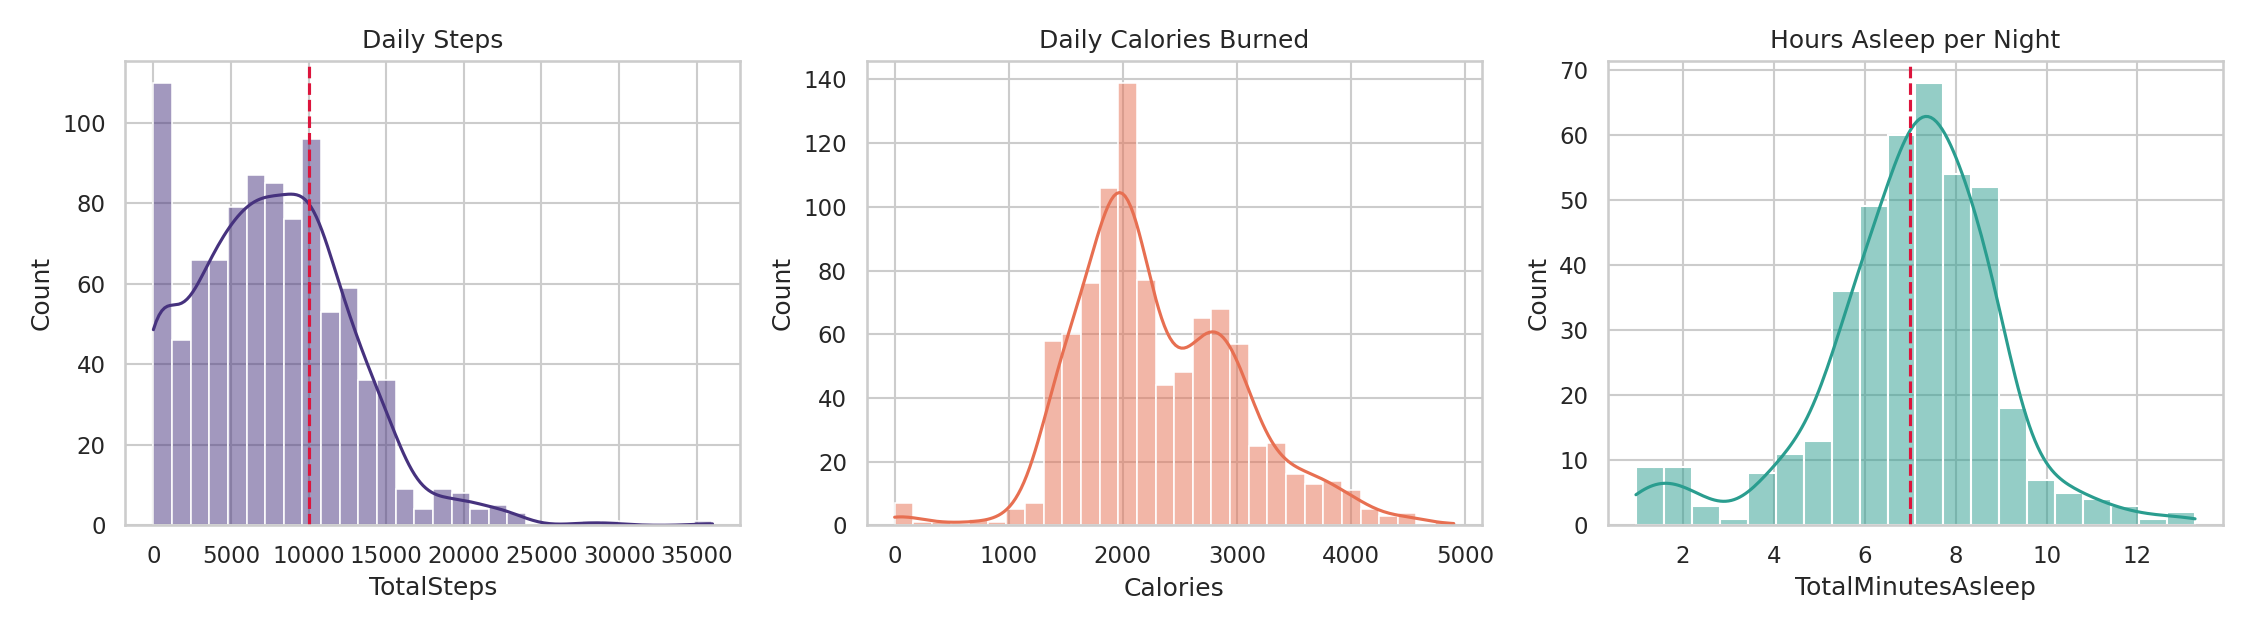

In [5]:
section("4. UNIVARIATE ANALYSIS")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.histplot(activity["TotalSteps"], bins=30, kde=True, ax=axes[0])
axes[0].axvline(10000, color="crimson", ls="--")
axes[0].set_title("Daily Steps")

sns.histplot(activity["Calories"], bins=30, kde=True, ax=axes[1], color="#e76f51")
axes[1].set_title("Daily Calories Burned")

sns.histplot(sleep["TotalMinutesAsleep"] / 60, bins=20, kde=True, ax=axes[2], color="#2a9d8f")
axes[2].axvline(7, color="crimson", ls="--")
axes[2].set_title("Hours Asleep per Night")
savefig(fig, "01_univariate_distributions.png")

print(f"Steps:    mean={activity.TotalSteps.mean():.0f}, median={activity.TotalSteps.median():.0f}, "
      f"skew={activity.TotalSteps.skew():.2f}")
print(f"Calories: mean={activity.Calories.mean():.0f}, median={activity.Calories.median():.0f}, "
      f"skew={activity.Calories.skew():.2f}")
print(f"Sleep(h): mean={(sleep.TotalMinutesAsleep/60).mean():.1f}, "
      f"median={(sleep.TotalMinutesAsleep/60).median():.1f}")

## 5. Bivariate / correlation analysis


5. BIVARIATE / CORRELATION ANALYSIS
  saved: 02_steps_vs_calories.png
  saved: 03_correlation_heatmap.png
Correlation matrix:
                     TotalSteps  ...  TotalTimeInBed
TotalSteps                1.00  ...           -0.16
TotalActiveMinutes        0.75  ...           -0.09
SedentaryMinutes         -0.13  ...           -0.62
Calories                  0.41  ...           -0.13
TotalMinutesAsleep       -0.19  ...            0.93
TotalTimeInBed           -0.16  ...            1.00

[6 rows x 6 columns]

n=413 matched activity+sleep days across 24 users


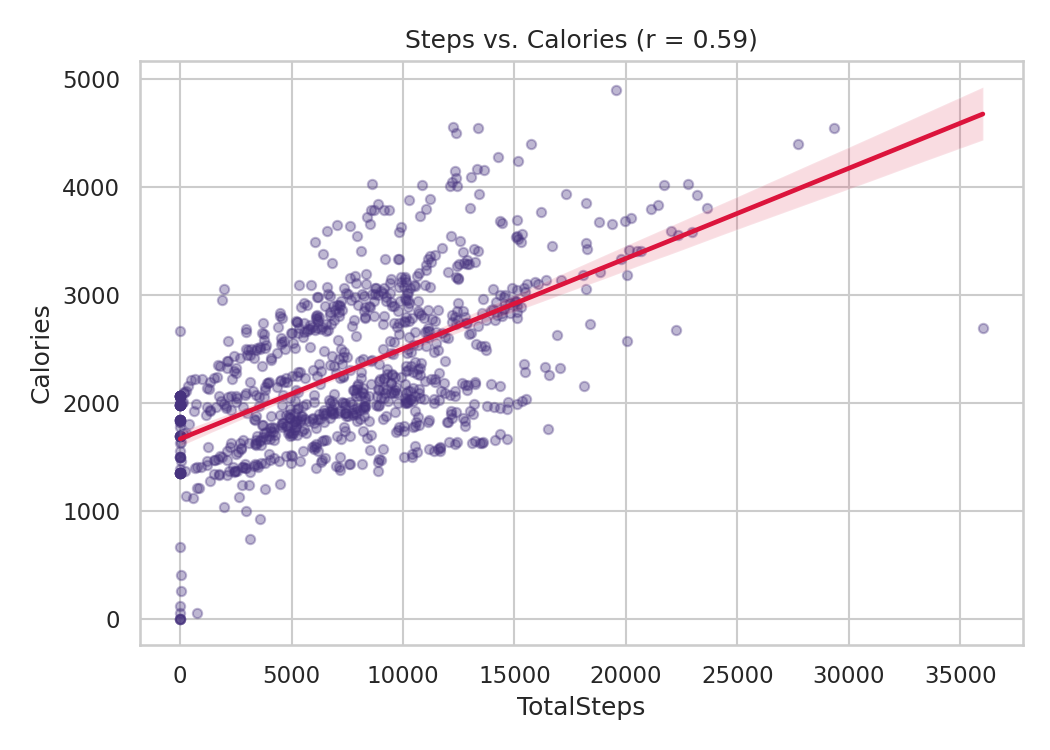

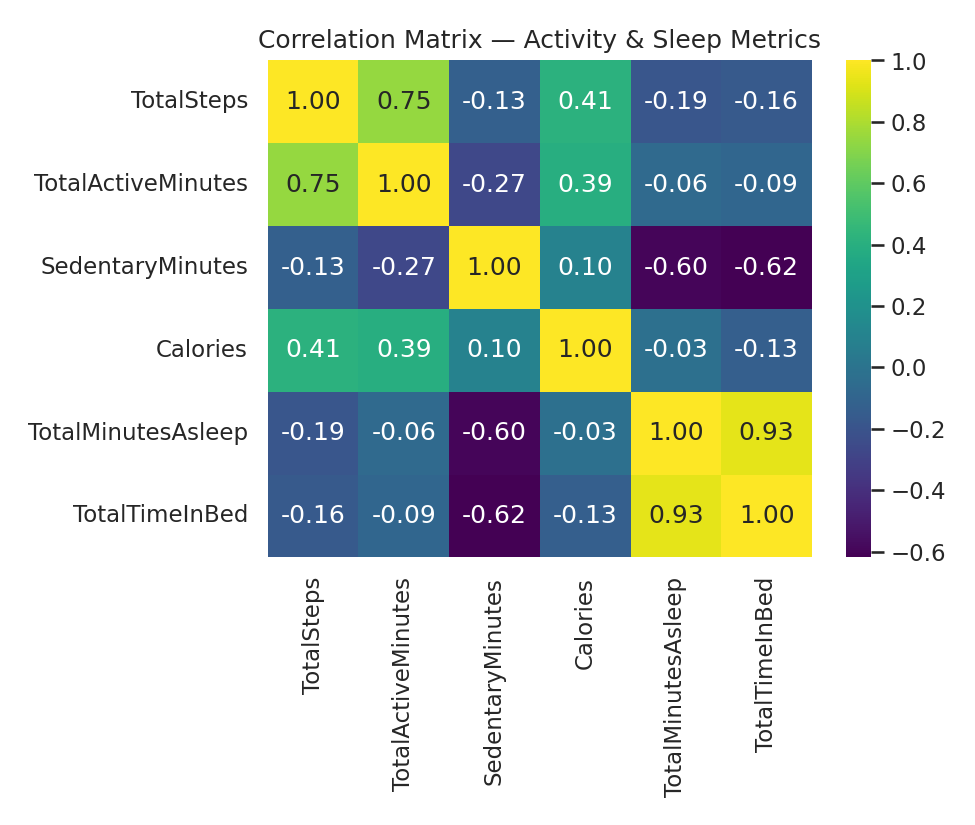

In [6]:
section("5. BIVARIATE / CORRELATION ANALYSIS")

fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=activity, x="TotalSteps", y="Calories",
            scatter_kws={"alpha": 0.35, "s": 20}, line_kws={"color": "crimson"}, ax=ax)
r = activity["TotalSteps"].corr(activity["Calories"])
ax.set_title(f"Steps vs. Calories (r = {r:.2f})")
savefig(fig, "02_steps_vs_calories.png")

# Merge activity + sleep for cross-metric correlation
merged = activity.merge(sleep, left_on=["Id", "ActivityDate"], right_on=["Id", "SleepDay"], how="inner")
corr_cols = ["TotalSteps", "TotalActiveMinutes", "SedentaryMinutes", "Calories", "TotalMinutesAsleep", "TotalTimeInBed"]
corr_matrix = merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Correlation Matrix — Activity & Sleep Metrics")
savefig(fig, "03_correlation_heatmap.png")

print("Correlation matrix:\n", corr_matrix.round(2))
print(f"\nn={len(merged)} matched activity+sleep days across {merged['Id'].nunique()} users")

## 6. Time-based patterns


6. TIME-BASED PATTERNS
  saved: 04_time_patterns.png
Avg steps by day of week:
 DayOfWeek
Monday       7781.0
Tuesday      8125.0
Wednesday    7559.0
Thursday     7406.0
Friday       7448.0
Saturday     8153.0
Sunday       6933.0
Name: TotalSteps, dtype: float64

Peak activity hour: 18:00 (599 avg steps)
Lowest activity hour: 3:00 (6 avg steps)


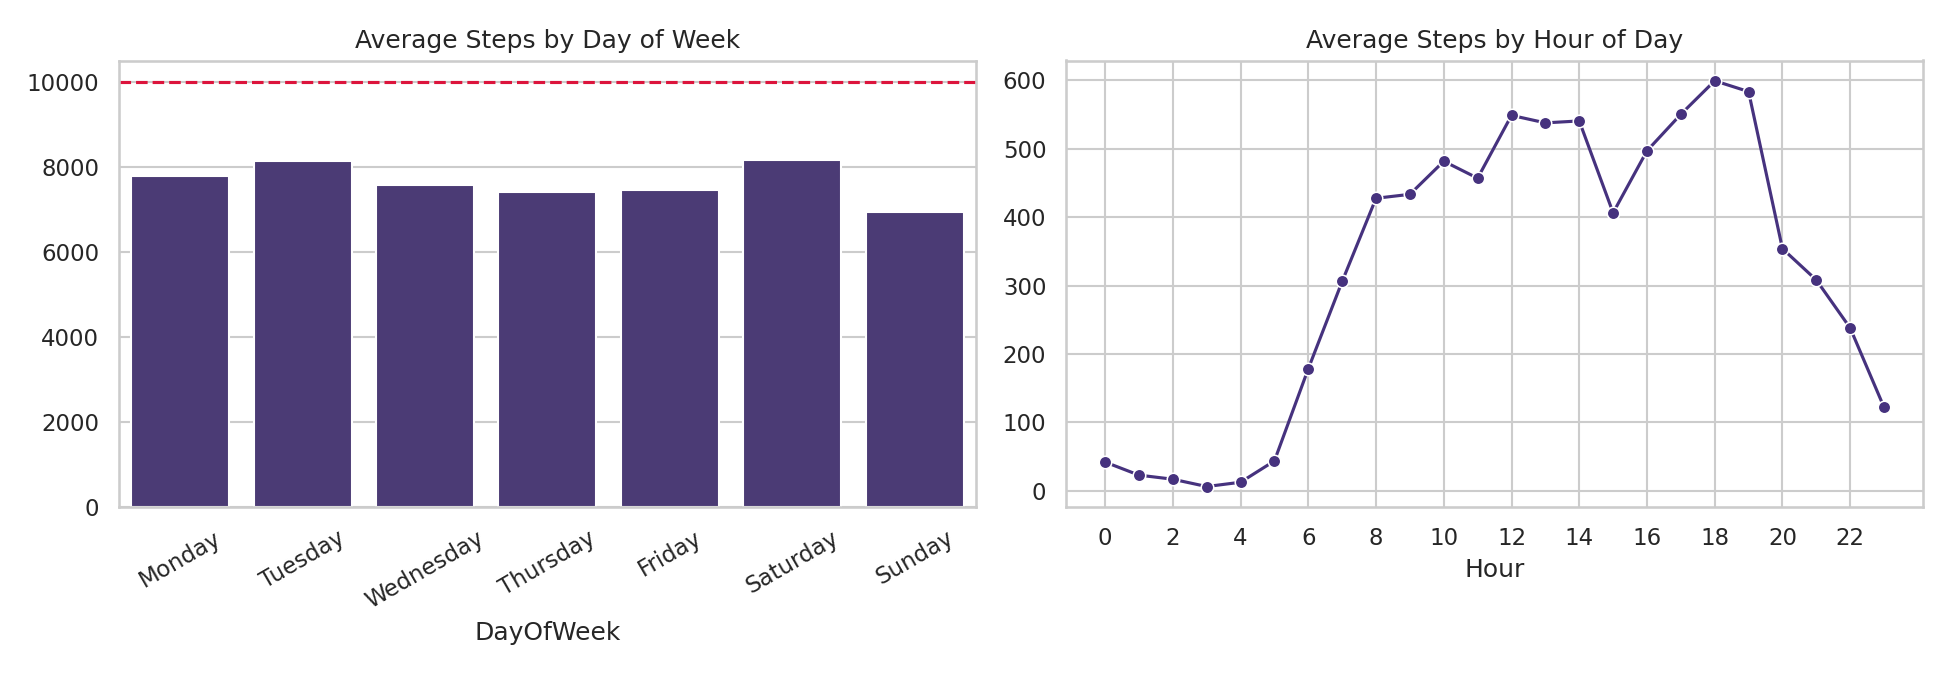

In [7]:
section("6. TIME-BASED PATTERNS")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
wk = activity.groupby("DayOfWeek")["TotalSteps"].mean().reindex(WEEKDAY_ORDER)
sns.barplot(x=wk.index, y=wk.values, ax=axes[0])
axes[0].axhline(10000, color="crimson", ls="--")
axes[0].set_title("Average Steps by Day of Week")
axes[0].tick_params(axis="x", rotation=30)

hourly_avg = hourly_steps.assign(Hour=hourly_steps["ActivityHour"].dt.hour).groupby("Hour")["StepTotal"].mean()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, marker="o", ax=axes[1])
axes[1].set_title("Average Steps by Hour of Day")
axes[1].set_xticks(range(0, 24, 2))
savefig(fig, "04_time_patterns.png")

print("Avg steps by day of week:\n", wk.round(0))
print(f"\nPeak activity hour: {hourly_avg.idxmax()}:00 ({hourly_avg.max():.0f} avg steps)")
print(f"Lowest activity hour: {hourly_avg.idxmin()}:00 ({hourly_avg.min():.0f} avg steps)")

## 7. Sleep deep-dive


7. SLEEP DEEP-DIVE
  saved: 05_sleep_efficiency.png
Median sleep efficiency: 94.3%
Nights under 7 hrs asleep: 43.9% of 410 nights
Median minutes awake while in bed: 26


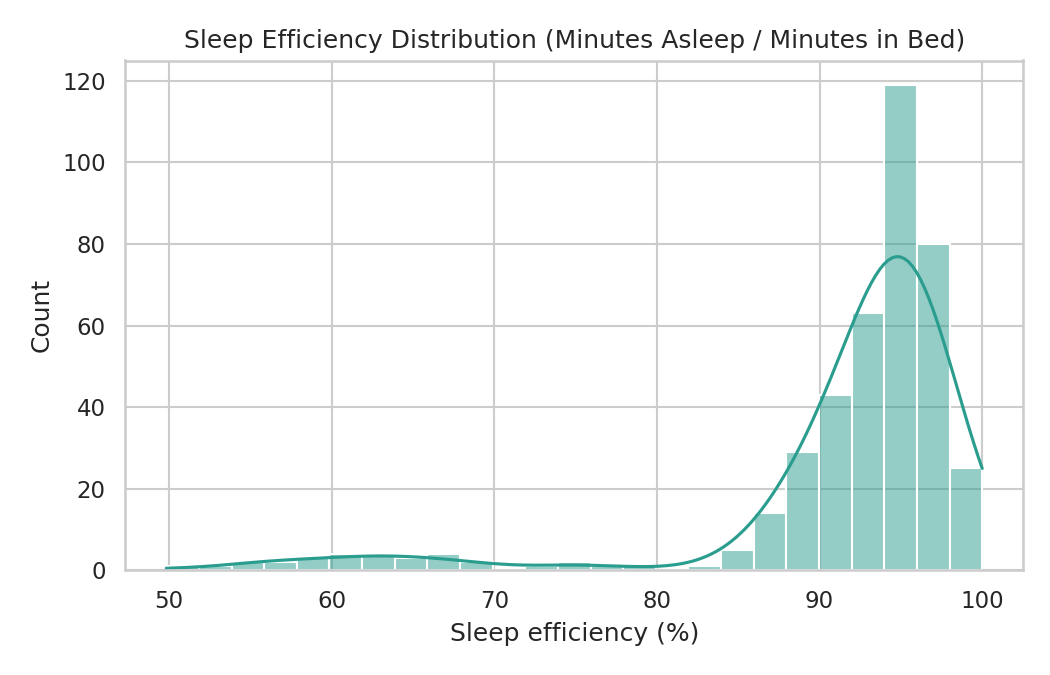

In [8]:
section("7. SLEEP DEEP-DIVE")

sleep_daily = (
    sleep.groupby(["Id", "SleepDay"], as_index=False)
    .agg(TotalMinutesAsleep=("TotalMinutesAsleep", "sum"), TotalTimeInBed=("TotalTimeInBed", "sum"))
)
sleep_daily["EfficiencyPct"] = 100 * sleep_daily["TotalMinutesAsleep"] / sleep_daily["TotalTimeInBed"]
sleep_daily["MinutesAwakeInBed"] = sleep_daily["TotalTimeInBed"] - sleep_daily["TotalMinutesAsleep"]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(sleep_daily["EfficiencyPct"], bins=25, kde=True, ax=ax, color="#2a9d8f")
ax.set_title("Sleep Efficiency Distribution (Minutes Asleep / Minutes in Bed)")
ax.set_xlabel("Sleep efficiency (%)")
savefig(fig, "05_sleep_efficiency.png")

print(f"Median sleep efficiency: {sleep_daily['EfficiencyPct'].median():.1f}%")
print(f"Nights under 7 hrs asleep: "
      f"{(sleep_daily['TotalMinutesAsleep'] < 420).mean()*100:.1f}% of {len(sleep_daily)} nights")
print(f"Median minutes awake while in bed: {sleep_daily['MinutesAwakeInBed'].median():.0f}")

## 8. Outlier check


8. OUTLIER CHECK (IQR method)
TotalSteps        : 12 outliers outside [-6616, 21133] (of 940 rows)
Calories          : 16 outliers outside [381, 4240] (of 940 rows)
SedentaryMinutes  : 0 outliers outside [-20, 1979] (of 940 rows)
  saved: 06_outlier_boxplots.png


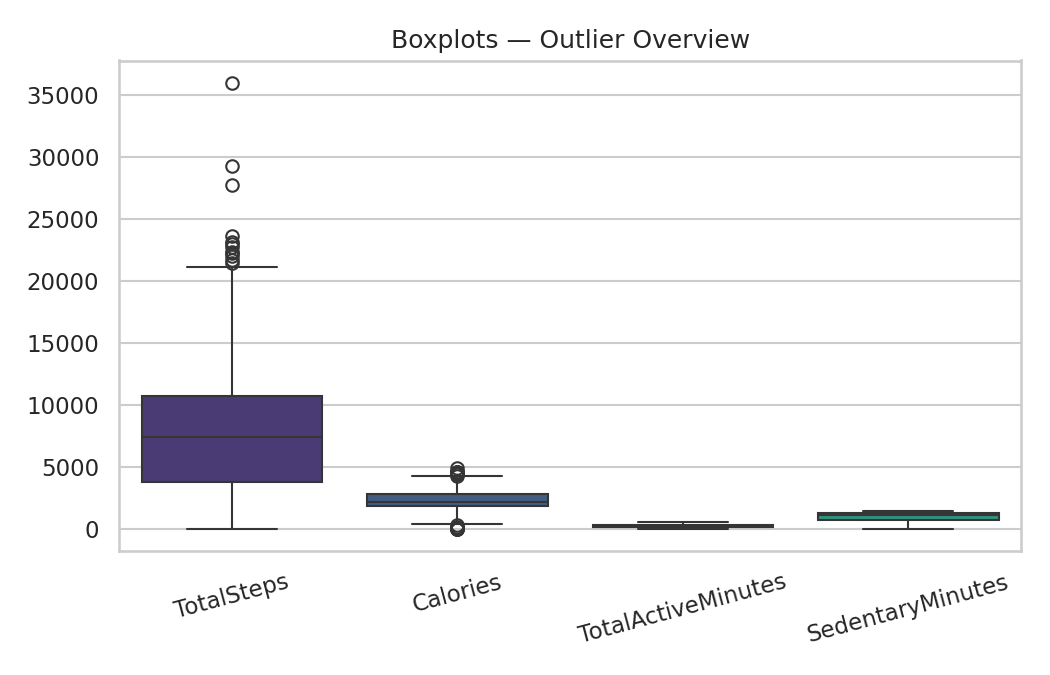

In [9]:
section("8. OUTLIER CHECK (IQR method)")

for col in ["TotalSteps", "Calories", "SedentaryMinutes"]:
    q1, q3 = activity[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((activity[col] < lo) | (activity[col] > hi)).sum()
    print(f"{col:18s}: {n_out} outliers outside [{lo:.0f}, {hi:.0f}] (of {len(activity)} rows)")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=activity[["TotalSteps", "Calories", "TotalActiveMinutes", "SedentaryMinutes"]], ax=ax)
ax.set_title("Boxplots — Outlier Overview")
ax.tick_params(axis="x", rotation=15)
savefig(fig, "06_outlier_boxplots.png")

## 9. Summary of findings

In [10]:
section("9. SUMMARY OF FINDINGS")

active_share = (activity.groupby("Id")["TotalSteps"].mean() >= 10000).mean()
print(f"""
- {activity['Id'].nunique()} users, {len(activity)} user-days ({activity['ActivityDate'].min().date()} to
  {activity['ActivityDate'].max().date()}), {activity['IsNoWearDay'].sum()} no-wear days flagged.
- Only {active_share*100:.0f}% of users average 10,000+ steps/day.
- Steps and calories are strongly correlated (r = {r:.2f}).
- Most active day of week: {wk.idxmax()} ({wk.max():.0f} avg steps);
  least active: {wk.idxmin()} ({wk.min():.0f} avg steps).
- Activity peaks around {hourly_avg.idxmax()}:00 and is lowest around {hourly_avg.idxmin()}:00.
- Median sleep efficiency is {sleep_daily['EfficiencyPct'].median():.1f}%, and
  {(sleep_daily['TotalMinutesAsleep'] < 420).mean()*100:.0f}% of logged nights fall short of 7 hours.
- Logging adherence drops sharply from activity ({activity['Id'].nunique()} users) to
  sleep ({sleep['Id'].nunique()} users) to weight ({weight['Id'].nunique()} users).

All charts saved to: {FIG_DIR}
""")


9. SUMMARY OF FINDINGS

- 33 users, 940 user-days (2016-04-12 to
  2016-05-12), 76 no-wear days flagged.
- Only 21% of users average 10,000+ steps/day.
- Steps and calories are strongly correlated (r = 0.59).
- Most active day of week: Saturday (8153 avg steps);
  least active: Sunday (6933 avg steps).
- Activity peaks around 18:00 and is lowest around 3:00.
- Median sleep efficiency is 94.3%, and
  44% of logged nights fall short of 7 hours.
- Logging adherence drops sharply from activity (33 users) to
  sleep (24 users) to weight (8 users).

All charts saved to: /home/claude/bellabeat_project/eda/eda_figures_full

